# Evaluating a linkage

Every number in chapters 2.3 to 2.7 was scored against a ground truth. Real data
does not come with one, and that is not a detail — it is the central difficulty
of linkage quality assessment.

This notebook does both halves. First, what evaluation looks like when labels
exist, because the bundled data has them and because a subset of your data may
too. Then the four practical methods for the ordinary case where nobody knows the
right answer.

**What you will do**

1. Produce a full accuracy analysis against labels, with Splink's own tools
2. Choose an operating threshold from evidence rather than by hand
3. Read the result against the blocking ceiling
4. Measure whether linkage error is **differential** — the question that decides
   whether a linked dataset is safe to publish from
5. Work through what to do when there are no labels at all

## 0. Setup

In [1]:
import unicodedata
from pathlib import Path

import pandas as pd

pd.set_option("display.max_columns", 25)
pd.set_option("display.width", 130)

DATA = Path("../../data")
if not DATA.exists():
    DATA = Path("data")

fonasa = pd.read_csv(DATA / "fonasa_sample.csv", dtype=str)
suseso = pd.read_csv(DATA / "suseso_sample.csv", dtype=str)


def basic_text_clean(series):
    return (series.astype("string").str.strip().str.upper()
            .str.replace(r"\s+", " ", regex=True))


def remove_accents(value):
    if pd.isna(value):
        return pd.NA
    value = unicodedata.normalize("NFKD", str(value))
    return "".join(c for c in value if not unicodedata.combining(c))


def standardise_name(series):
    cleaned = basic_text_clean(series)
    cleaned = cleaned.map(remove_accents, na_action="ignore").astype("string")
    cleaned = cleaned.str.replace(r"[^A-ZN ]", "", regex=True)
    return cleaned.str.replace(r"\s+", " ", regex=True).str.strip()


def clean_sex(series):
    cleaned = basic_text_clean(series)
    return cleaned.replace({"HOMBRE": "M", "MUJER": "F", "MASCULINO": "M",
                            "FEMENINO": "F", "": pd.NA})


for df in (fonasa, suseso):
    for col in ["nombre", "ap1", "ap2"]:
        df[f"{col}_clean"] = standardise_name(df[col])
    df["sexo_clean"] = clean_sex(df["sexo"])
    df["nac_clean"] = basic_text_clean(df["nacionalidad"])

CLEAN = ["nombre_clean", "ap1_clean", "ap2_clean", "sexo_clean", "nac_clean"]
TRUE_MATCHES = 4500

print(f"fonasa: {len(fonasa):,} records | suseso: {len(suseso):,} records")
print(f"true matches present in the data: {TRUE_MATCHES:,}")


import phonetics


def dmeta_primary(value):
    """Primary Double Metaphone code, as a string. Used for blocking."""
    if pd.isna(value) or value == "":
        return None
    try:
        return phonetics.dmetaphone(str(value))[0] or None
    except Exception:
        return None


def dmeta_list(value):
    """Both Double Metaphone codes, as a list. This is the form Splink's
    comparison functions expect for a `dmeta_col_name` argument."""
    if pd.isna(value) or value == "":
        return None
    try:
        return [c for c in phonetics.dmetaphone(str(value)) if c] or None
    except Exception:
        return None


for df in (fonasa, suseso):
    for col in ["nombre_clean", "ap1_clean", "ap2_clean"]:
        stem = col.replace("_clean", "")
        df[f"{stem}_dm"] = df[col].map(dmeta_primary)      # string, for blocking
        df[f"{stem}_dmeta"] = df[col].map(dmeta_list)      # list, for comparisons

MODEL_COLS = (["unique_id"] + CLEAN
              + ["nombre_dm", "ap1_dm", "ap2_dm"]
              + ["nombre_dmeta", "ap1_dmeta", "ap2_dmeta"])
fonasa_m = fonasa[MODEL_COLS + ["true_person_id"]].copy()
suseso_m = suseso[MODEL_COLS + ["true_person_id"]].copy()

print("phonetic example:  GONZALEZ ->",
      dmeta_primary("GONZALEZ"), "(blocking) /", dmeta_list("GONZALEZ"), "(comparison)")

fonasa: 30,000 records | suseso: 27,000 records
true matches present in the data: 4,500
phonetic example:  GONZALEZ -> KNSLS (blocking) / ['KNSLS'] (comparison)


In [2]:
from pathlib import Path
from splink import DuckDBAPI, Linker
import vl_convert as vlc
from IPython.display import Image


def show(chart, scale=2):
    return Image(vlc.vegalite_to_png(chart.to_json(), scale=scale))


MODEL_DIR = Path("../../models")
if not MODEL_DIR.exists():
    MODEL_DIR = Path("models")

linker = Linker(
    input_table_or_tables=[fonasa_m, suseso_m],
    settings=str(MODEL_DIR / "linkage-model.json"),
    db_api=DuckDBAPI(),
    input_table_aliases=["fonasa", "suseso"],
)
df_predict = linker.inference.predict()
predictions = df_predict.as_pandas_dataframe()
predictions["is_true_match"] = (
    predictions["true_person_id_l"] == predictions["true_person_id_r"]
)
print(f"model loaded; {len(predictions):,} candidate pairs scored")

Blocking time: 0.07 seconds
Predict time: 0.12 seconds


model loaded; 8,868 candidate pairs scored


## Part 1 — When you have labels

The bundled registers carry `true_person_id`. Splink can evaluate a model
directly against such a column.

In [3]:
accuracy = linker.evaluation.accuracy_analysis_from_labels_column(
    "true_person_id",
    output_type="table",
).as_pandas_dataframe()

print(f"{len(accuracy)} threshold settings evaluated")
accuracy[["truth_threshold", "match_probability", "tp", "fp", "fn",
          "precision", "recall", "f1"]].head(8).round(4)

Blocking time: 0.05 seconds
Predict time: 0.11 seconds


840 threshold settings evaluated


,truth_threshold,match_probability,tp,fp,fn,precision,recall,f1
0,-91.5,0.0,1882.0,6986.0,2618.0,0.2122,0.4182,0.2816
1,-90.5,0.0,1882.0,6913.0,2618.0,0.2140,0.4182,0.2831
2,-89.8,0.0,1882.0,6899.0,2618.0,0.2143,0.4182,0.2834
3,-89.4,0.0,1882.0,6887.0,2618.0,0.2146,0.4182,0.2837
4,-89.1,0.0,1882.0,6861.0,2618.0,0.2153,0.4182,0.2842
5,-88.1,0.0,1882.0,6845.0,2618.0,0.2157,0.4182,0.2846
6,-87.7,0.0,1882.0,6829.0,2618.0,0.2160,0.4182,0.2849
7,-87.4,0.0,1882.0,6812.0,2618.0,0.2165,0.4182,0.2853


```{warning}
The `truth_threshold` column is in **match weight** units (log-odds, roughly
−48 to +30 here), **not** in match probability. Passing it straight to an
argument expecting `threshold_match_probability` produces a nonsensical
threshold and no error message.

Use the `match_probability` column of the same table for that purpose. This is an
easy mistake to make and a hard one to notice.
```

### Choosing the operating threshold from evidence

Chapter 2.1 recorded that this use case weights the two errors equally. That,
and only that, is what makes maximising F1 the right rule here.

In [4]:
best = accuracy.loc[accuracy["f1"].idxmax()]

print(f"F1-optimal threshold")
print(f"  match probability : {best['match_probability']:.4f}")
print(f"  match weight      : {best['truth_threshold']:.4f}")
print(f"  precision         : {best['precision']:.4f}")
print(f"  recall            : {best['recall']:.4f}")
print(f"  F1                : {best['f1']:.4f}")
print(f"  true positives    : {int(best['tp']):,}")
print(f"  false positives   : {int(best['fp']):,}")
print(f"  false negatives   : {int(best['fn']):,}")

F1-optimal threshold
  match probability : 0.0055
  match weight      : -7.5000
  precision         : 0.8256
  recall            : 0.3578
  F1                : 0.4992
  true positives    : 1,610
  false positives   : 340
  false negatives   : 2,890


And here is why "maximise F1" should never be a reflex.

The F1-optimal threshold is a match probability of **0.0055** — extraordinarily
permissive. It accepts anything the model rates above roughly one chance in two
hundred. At that setting precision is **0.83**: about one accepted pair in six is
wrong.

F1 pushed the threshold there because on this data recall is scarce and precision
is abundant, so the harmonic mean is maximised by trading a lot of precision for
a little recall. That is the correct answer to the question "what maximises F1",
and quite possibly the wrong answer for your use case.

Compare with the operating point used in chapter 2.7:

| Threshold | Precision | Recall | Accepted pairs |
|:--|--:|--:|--:|
| 0.90 (chapter 2.7) | 0.9961 | 0.2804 | 1,267 |
| 0.0055 (F1-optimal) | 0.8256 | 0.3578 | 1,950 |

Same model, same data, two defensible datasets with very different properties.
Moving to the F1-optimal point buys about 350 extra true matches and admits about
340 wrong ones. If a wrong link has any real-world consequence, that is a bad
trade regardless of what F1 says.

The threshold is a **policy decision informed by measurement**, not an
optimisation. Pick the row of this table that matches the error preference you
wrote down in chapter 2.1.

Blocking time: 0.04 seconds
Predict time: 0.06 seconds


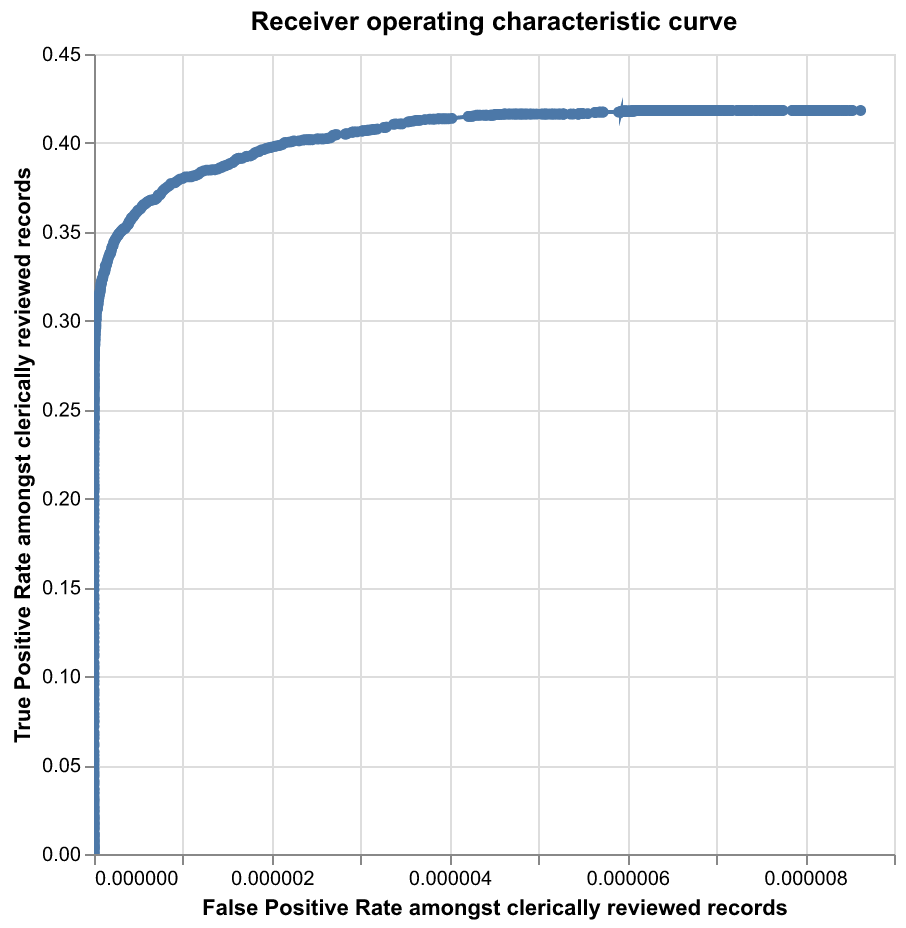

In [5]:
show(linker.evaluation.accuracy_analysis_from_labels_column(
    "true_person_id", output_type="roc"))

Blocking time: 0.04 seconds
Predict time: 0.06 seconds


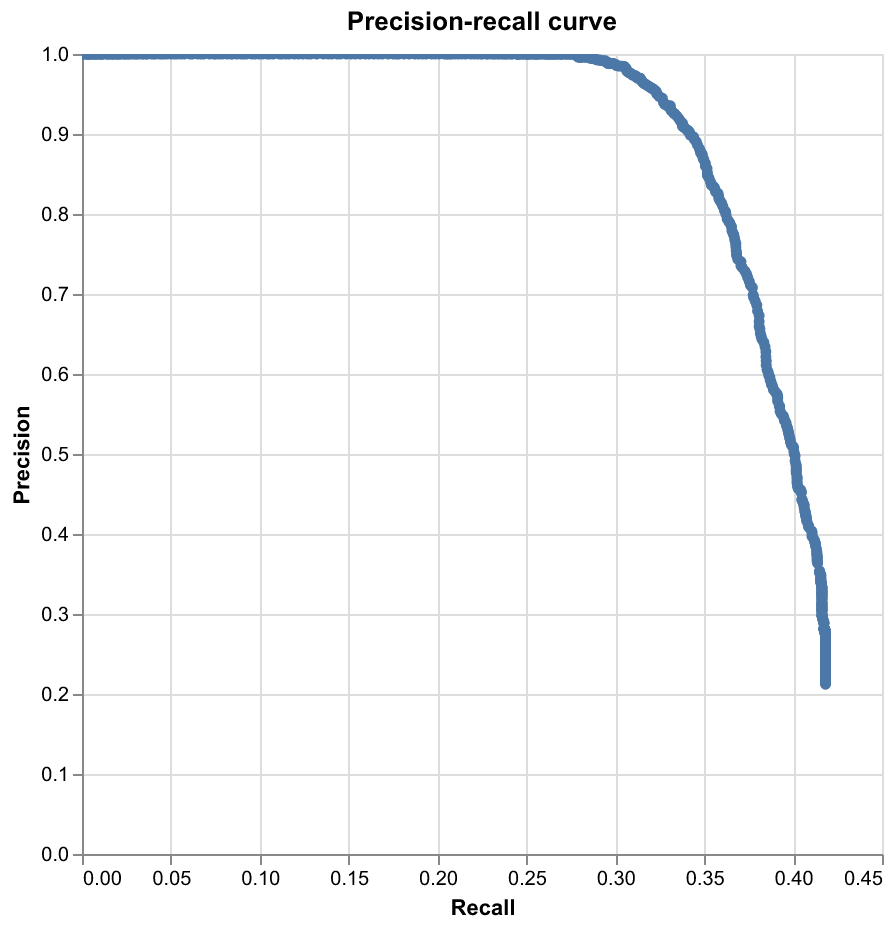

In [6]:
show(linker.evaluation.accuracy_analysis_from_labels_column(
    "true_person_id", output_type="precision_recall"))

The precision-recall curve is the more informative of the two for linkage,
because the classes are so unbalanced: 4,500 matches among 810 million possible
pairs. An ROC curve looks flattering under that imbalance, because the false
positive rate has an enormous denominator.

Read the precision-recall curve for the shape of the cliff. A curve that stays
high and then falls sharply means there is a clean operating point. A curve that
declines steadily means every gain in recall costs precision immediately.

### Reading recall against the ceiling

A recall figure on its own is misleading, because it silently blames the model
for matches that blocking discarded.

In [7]:
BLOCKING_CEILING = 0.4182     # measured in chapter 2.5
TRUE_MATCHES = 4500

reachable = BLOCKING_CEILING * TRUE_MATCHES
found = best["tp"]

print(f"True matches in the data              : {TRUE_MATCHES:,}")
print(f"Reachable after blocking              : {reachable:,.0f}  ({BLOCKING_CEILING:.1%})")
print(f"Found by the model at this threshold  : {found:,.0f}")
print()
print(f"Recall against all true matches       : {found/TRUE_MATCHES:.4f}")
print(f"Recall against what blocking allowed  : {found/reachable:.4f}")
print()
print(f"Lost to blocking : {TRUE_MATCHES - reachable:,.0f} matches")
print(f"Lost to the model: {reachable - found:,.0f} matches")

True matches in the data              : 4,500
Reachable after blocking              : 1,882  (41.8%)
Found by the model at this threshold  : 1,610

Recall against all true matches       : 0.3578
Recall against what blocking allowed  : 0.8555

Lost to blocking : 2,618 matches
Lost to the model: 272 matches


Those last two lines are the ones to act on. On this data blocking discards
**2,618** matches and the model misses **272** — blocking loses roughly ten times
as many. Effort spent on blocking rules will pay back many times more than effort
spent tuning the model, which is not where attention naturally goes.

Report both figures. A quality statement that gives only the first invites the
reader to think the model is worse than it is; one that gives only the second
hides a real loss.

## Part 2 — Is the error differential?

This is the question that decides whether a linked dataset is safe to publish
from, and it is more important than the headline error rate.

Errors that fall **evenly** across the population inflate variance and can often
be corrected for. Errors concentrated in a **particular group** bias every
estimate that compares groups — and administrative data errors are almost never
evenly distributed.

We have the truth here, so we can measure it directly.

In [8]:
truth = fonasa_m.merge(
    suseso_m[["unique_id", "true_person_id"]], on="true_person_id",
    suffixes=("", "_s"),
)

THRESHOLD = float(best["match_probability"])
found_pairs = set(
    predictions.loc[predictions["match_probability"] >= THRESHOLD, "unique_id_l"]
)
truth["was_found"] = truth["unique_id"].isin(found_pairs)

print(f"Recall by subgroup, at threshold {THRESHOLD:.4f}")
print()
for field, label in [("nac_clean", "nationality"), ("sexo_clean", "sex")]:
    tbl = truth.groupby(field, dropna=False).agg(
        true_matches=("was_found", "size"),
        found=("was_found", "sum"),
    )
    tbl["recall"] = (tbl["found"] / tbl["true_matches"]).round(4)
    print(f"By {label}:")
    print(tbl.to_string())
    print()

Recall by subgroup, at threshold 0.0055

By nationality:
            true_matches  found  recall
nac_clean                              
CHILENA             3351   1212  0.3617
EXTRANJERA           927    370  0.3991
<NA>                 222     52  0.2342

By sex:
            true_matches  found  recall
sexo_clean                             
F                   2059    780  0.3788
M                   2307    826  0.3580
<NA>                 134     28  0.2090



Read the recall column across groups.

By nationality and by sex the differences are modest. But look at the records
where those fields are **missing**: recall drops to 0.23 and 0.21 against roughly
0.36 for everyone else. Records with incomplete identifying information are
substantially less likely to be linked, which is exactly the group least likely
to be well served by administrative systems in the first place.

If recall varies across groups, linkage error is **differential**, and any
statistic comparing those groups in the linked dataset is biased — not noisy,
biased, and now in a direction you can name.

This is not a hypothetical concern. Linkage depends on name quality, and name
quality in administrative registers commonly varies with nationality,
transliteration, migration status, age and how recently a record was created:
precisely the characteristics that analyses of linked data care about.

In [9]:
# Does the length of a name affect whether it gets linked?
truth["name_length"] = truth["nombre_clean"].str.len()
bands = pd.cut(truth["name_length"], [0, 6, 10, 15, 100],
               labels=["1-6", "7-10", "11-15", "16+"])
tbl = truth.groupby(bands, observed=False).agg(
    true_matches=("was_found", "size"), found=("was_found", "sum"))
tbl["recall"] = (tbl["found"] / tbl["true_matches"]).round(4)
tbl

,true_matches,found,recall
name_length,,,
1-6,684,127,0.1857
7-10,866,211,0.2436
11-15,1907,865,0.4536
16+,809,380,0.4697


That gradient is unambiguous: recall rises from **0.19** for the shortest given
names to **0.47** for the longest. Nothing in the model treats short names badly.
A short name simply carries less information, so agreement on it is weaker
evidence and the pair scores lower.

The consequence is a linked dataset that systematically under-represents people
with short names — which correlates with naming conventions, and therefore with
ethnicity, language and migration history. This is how a purely technical
property of a linkage becomes a substantive bias in a published statistic.

Four questions to answer about any linked dataset before publishing from it:

1. **Who is missing?** Compare the characteristics of records that linked with
   those that did not.
2. **Does the linkage rate vary across the groups your analysis compares?** If
   yes, differences between those groups are partly an artefact of linkage.
3. **Which direction does the bias run?** Missed matches usually understate
   overlap; false matches usually attenuate real differences.
4. **Would your conclusion change under a different threshold?** If it would,
   report the sensitivity rather than one number.

## Part 3 — When you have no labels

The normal case. Four practical methods, in rough order of how much they cost.

### 1. Compare linked, unlinked and unlinkable records

The cheapest and most informative check, and it needs no external data. Split
your records into three groups and compare their observed characteristics.

In [10]:
fonasa_eval = fonasa_m.copy()
fonasa_eval["status"] = "unlinked"
fonasa_eval.loc[fonasa_eval["unique_id"].isin(found_pairs), "status"] = "linked"
# 'unlinkable': could never have matched, because a key field is missing
unlinkable = fonasa_eval[["nombre_clean", "ap1_clean"]].isna().any(axis=1)
fonasa_eval.loc[unlinkable & (fonasa_eval["status"] == "unlinked"), "status"] = "unlinkable"

profile = fonasa_eval.groupby("status").agg(
    records=("unique_id", "size"),
    pct_foreign=("nac_clean", lambda s: round(100 * (s == "EXTRANJERA").mean(), 2)),
    pct_female=("sexo_clean", lambda s: round(100 * (s == "F").mean(), 2)),
    mean_name_length=("nombre_clean", lambda s: round(s.str.len().mean(), 1)),
)
profile

,records,pct_foreign,pct_female,mean_name_length
status,,,,
linked,1904,21.40,47.11,12.8
unlinkable,2763,18.11,47.58,10.1
unlinked,25333,17.51,49.59,12.0


Differences between the rows are evidence about who the linkage is losing —
available without any ground truth, from data you already hold. Here, linked
records have noticeably longer given names than unlinkable ones, which is the
same signal the labelled analysis found, recovered without labels.

Separating **unlinkable** records from merely **unlinked** ones matters. An
unlinkable record never had a chance, usually because a key field is missing;
lumping the two together confuses a data-collection problem with a linkage
problem, and they have different remedies.

One honest limitation: the "unlinked" group mixes records whose partner was
missed with records that have **no partner at all** — most of these registers do
not overlap. On real data you cannot separate those two, which is precisely why
this check is suggestive rather than conclusive. It tells you where to look, not
what the error rate is.

### 2. Compare against external reference data

If an independent source gives a known total — a census count, a published
register size, an administrative total — compare your linked count against it.
This will not identify *which* links are wrong, but it bounds the aggregate
error, which is often what a published statistic needs.

### 3. Build a gold standard on a subset

Take a sample of pairs, have people adjudicate them, and treat the result as
truth for that sample. This is the only method that produces direct estimates of
precision and recall without a full ground truth.

Sample deliberately rather than at random. Random sampling from 8,868 candidate
pairs mostly returns obvious non-matches and teaches you little. Stratify by
score, and over-sample the region where the model is uncertain — the borderline
band from chapter 2.7, where 79% of pairs were genuine matches and every one of
them was a judgement call.

Splink provides a tool that renders one record's candidate matches for human
adjudication.

In [11]:
example_id = predictions.sort_values("match_probability").iloc[len(predictions)//2]["unique_id_l"]

dashboard = linker.evaluation.labelling_tool_for_specific_record(
    unique_id=example_id,
    source_dataset="fonasa",
    out_path="outputs/labelling-tool.html",
    overwrite=True,
)
print(f"labelling tool written for record {example_id} -> outputs/labelling-tool.html")


The Splink labelling tool is still in development, which means some features may change and there may be bugs.
Your feedback will help us improve it. Go to
github.com/moj-analytical-services/splink/discussions/new?category=general
to give us feedback.


labelling tool written for record F0015774 -> outputs/labelling-tool.html


The output is a self-contained HTML page showing the record and every candidate
match with its score and field-by-field comparison, with buttons to record a
judgement. Reviewers work through a stratified sample of these, and the labelled
results become the gold standard.

### 4. Plausibility checks

Internal consistency checks that need nothing external, and catch a surprising
amount:

- **Structure.** In a 1:1 link, no record should match several others. Chapter
  2.7 found no clusters larger than two, which is real evidence.
- **Impossible combinations.** A person linked to records implying two different
  dates of birth, or a death preceding a birth.
- **Distribution.** If your registers should overlap in roughly 15% of records
  and the linkage finds 3%, something is wrong regardless of what precision says.
- **Positive and negative controls.** Take records you *know* should link (a
  clerically confirmed set) and check the model finds them. Take records that
  cannot possibly link — different periods, disjoint populations — and check that
  it does not.

### How to choose

| Method | Cost | Gives you | Main limitation |
|:--|:--|:--|:--|
| Linked vs unlinked profiling | Very low | Evidence on differential error | Says nothing about false matches |
| External reference totals | Low | An aggregate bound | Cannot identify individual errors |
| Clerical gold standard | High | Direct precision and recall | Sampling design is easy to get wrong |
| Plausibility checks | Low | Structural errors, quickly | Passing them does not mean correct |

Do the first and the fourth always: they are nearly free. Do the third when the
output will be published or used to make decisions about individuals. The second
when an independent total exists.

**Never report a match rate on its own.** A match rate is not a quality measure:
it is one number that mixes true matches, false matches and genuine overlap, and
it can be increased simply by lowering the threshold.

## What to record

The evaluation belongs in the documentation, with these elements at minimum:

- the threshold, in both match-probability and match-weight terms;
- precision and recall, with how they were estimated and on what sample;
- recall stated against the blocking ceiling as well as against all true matches;
- the linked / unlinked / unlinkable profile;
- whether error is differential, across which characteristics, and in which
  direction;
- structural checks and their results;
- everything you could not measure, said plainly.

[Chapter 2.9](end-to-end-example.md) puts the whole pipeline into a single
notebook, and Section 3 turns these results into a quality statement fit for
publication.